In [1]:
print("all ryt")


all ryt


In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq

In [4]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [5]:
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing in your .env")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [6]:
from langchain_groq import ChatGroq

chat_llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model="openai/gpt-oss-20b"
)

In [7]:
chat_llm.invoke("Hello, How are you?").content

'Hello! I’m doing great—thanks for asking. How can I help you today?'

In [8]:
from typing_extensions import TypedDict, Annotated
import operator

In [9]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [10]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [11]:
{
    "messages": [HumanMessage(content="Hi, this is Moosa, Say hello in details")]
}

{'messages': [HumanMessage(content='Hi, this is Moosa, Say hello in details', additional_kwargs={}, response_metadata={})]}

In [12]:
["hi"]

['hi']

In [13]:
["hi","how are you"]

['hi', 'how are you']

In [14]:
def llm_call(state: GraphState) -> dict:
    """"Call the LLM using conversation messages and appemnd AI message."""
    response = chat_llm.invoke(state["messages"]) # AIMessage
    return{
        "messages": [response]
    }

In [15]:
def token_counter(state: GraphState) -> dict:
    """"Count tokens (simple word count) in the last AI message"""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return{
        "messages": [AIMessage(content=summary)]
    }

In [16]:
from langgraph.graph import StateGraph

In [17]:
builder = StateGraph(GraphState)

In [18]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [19]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [20]:
app = builder.compile()

In [21]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [22]:
from IPython.display import Image, display

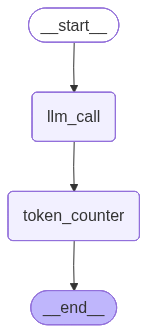

In [23]:
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Moosa, Say hello in details")]
})

In [25]:
result

{'messages': [HumanMessage(content='Hi, this is Moosa, Say hello in details', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello, Moosa! 👋\n\nIt’s a beautiful day in 2026—March 5th, to be exact. The sun’s shining, and the world is humming with the quiet buzz of everyday life. I’m here, ready to chat, help, or simply share a moment of curiosity with you.\n\nHow are you doing today? Anything exciting happening in your world? Whether you’re tackling a project, looking for a quick recipe, or just want to explore a random fact, I’ve got you covered. Feel free to drop a question, a thought, or even just a hello. I’m all ears (or, well, all text, but you get the idea)! 🌟', additional_kwargs={'reasoning_content': 'The user says: "Hi, this is Moosa, Say hello in details". They want a detailed hello. We should greet them warmly, mention details: perhaps ask about their day, how they are, mention the time, location, etc. The user didn\'t specify a particular context. Just a f

In [26]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Moosa, Say hello in details
AIMessage : Hello, Moosa! 👋

It’s a beautiful day in 2026—March 5th, to be exact. The sun’s shining, and the world is humming with the quiet buzz of everyday life. I’m here, ready to chat, help, or simply share a moment of curiosity with you.

How are you doing today? Anything exciting happening in your world? Whether you’re tackling a project, looking for a quick recipe, or just want to explore a random fact, I’ve got you covered. Feel free to drop a question, a thought, or even just a hello. I’m all ears (or, well, all text, but you get the idea)! 🌟
AIMessage : Total token number in the generated answer (word count) is 102


In [27]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper


In [28]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [29]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [31]:
wiki_tool.run({"query": "Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [61]:
import os
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")


In [62]:
TAVILY_API_KEY

'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'

In [63]:
tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [64]:
tool.invoke({"query": "how is the job market for fresh graduates 2026"})

[{'title': 'The 2026 Job Market: Supporting Students and Closing the Skills Gap',
  'url': 'https://findingequilibriumfuturehighered.substack.com/p/the-2026-job-market-supporting-students',
  'content': "### Ideas for Preparing More Career-Ready Graduates\n\nImage 3: Jay Akridge's avatarImage 4: David Hummels's avatar\n\nJay Akridge and David Hummels\n\nDec 19, 2025\n\n13\n\n13\n\nShare\n\nWe’ve written a couple of times this fall on the current job market for new college graduates. The bottom-line: the Class of 2026 is likely to have more trouble finding a job.\n\nStudents are concerned: about 61% of the Class of 2026 students find current news about the job market somewhat or very pessimistic – up from 50% for the Class of 2024. High competition for jobs and lack of available jobs top the list of reasons for that pessimism, with the political climate and AI much more important factors this year relative to last.\n\nImage 5\n\nSource: Handshake. [...] #### Some Final Thoughts\n\nA sof

In [65]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()

In [66]:
search.invoke("What is the latest update on iphone17 release?")

"17 Oct 2025·Original: iOS 26. Current: iOS 26.3, released February 11, 2026. System-on-chip · Apple A19 · Modem · Qualcomm Snapdragon X80. Memory, 8 GB LPDDR5X. Storage ... 01 Sept 2025·Apple's Upcoming Releases, iPhone 17 Pro, iOS 18.7 and iOS 26 RC Soon - iOS 26 RC is expected soon. iPhone 17 could get a new style case and iPhone 17 Pro ... 3 days ago·... Release Date and Price Details GET NEW AIRPODS HERE (Amazon Links) ... updates on the iPhone 17 Pro and other tech news. Hit the notification bell ... 3 days ago·The new iPhone 17e, a budget-friendly version of the iPhone 17, is available for pre-order on March 4 and in stores on March 11. 13 Feb 2026·The iPhone 17 was released in September 2025, which means now is a good time to buy. A new model is not expected until early 2027, because Apple is changing ...Should You Buy an iPhone 17?·The 2025 iPhone 17"

"17 Oct 2025·Original: iOS 26. Current: iOS 26.3, released February 11, 2026. System-on-chip · Apple A19 · Modem · Qualcomm Snapdragon X80. Memory, 8 GB LPDDR5X. Storage ... 01 Sept 2025·Apple's Upcoming Releases, iPhone 17 Pro, iOS 18.7 and iOS 26 RC Soon - iOS 26 RC is expected soon. iPhone 17 could get a new style case and iPhone 17 Pro ... 3 days ago·... Release Date and Price Details GET NEW AIRPODS HERE (Amazon Links) ... updates on the iPhone 17 Pro and other tech news. Hit the notification bell ... 3 days ago·The new iPhone 17e, a budget-friendly version of the iPhone 17, is available for pre-order on March 4 and in stores on March 11. 13 Feb 2026·The iPhone 17 was released in September 2025, which means now is a good time to buy. A new model is not expected until early 2027, because Apple is changing ...Should You Buy an iPhone 17?·The 2025 iPhone 17"